In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.io import loadmat
import pandas as pd
import seaborn as sns

In [2]:
subList = [1, 2, 3, 4, 5, 6, 7, 9, 10, 12, 13, 15, 17, 
           18, 19, 23, 24, 25, 26, 27, 28, 29, 31, 32]

# df = pd.DataFrame(columns=['subjID', 'rnum', 'tnum', 'error', 'reaction_time', 'velocity', 'tarloc', 'tarlocCode', 'rejtrials'])

for sIdx, subjID in enumerate(subList):
    print('Reading data for subject %d' % subjID)
    bidsRoot = '/System/Volumes/Data/d/DATD/datd/MEG_MGS/MEG_BIDS'
    taskName = 'mgs'
    subName = 'sub-%02d' % subjID
    print('Loading gaze data for ' + subName)
    derivativesRoot = os.path.join(bidsRoot, 'derivatives', subName)
    eyeRoot = os.path.join(derivativesRoot, 'eyetracking')
    megRoot = os.path.join(derivativesRoot, 'meg')
    fNameRoot = subName + '_task-' + taskName
    iisess_fpath = os.path.join(eyeRoot, fNameRoot + '-iisess.mat')
    ii_sess = loadmat(iisess_fpath)
    error = ii_sess['ii_sess']['i_sacc_err'][0, 0].T[0]
    reaction_time = ii_sess['ii_sess']['i_sacc_rt'][0, 0].T[0]
    velocity = ii_sess['ii_sess']['i_sacc_peakvel'][0, 0].T[0]
    tarloc = ii_sess['ii_sess']['tarloc'][0, 0].T[0]
    tarlocCode = ii_sess['ii_sess']['tarlocCode'][0, 0].T[0]
    tarlocCode = tarlocCode.astype(int)
    tarloc = tarloc.astype(int)
    rnum = ii_sess['ii_sess']['r_num'][0, 0].T[0]
    tnum = ii_sess['ii_sess']['t_num'][0, 0].T[0]
    rejtrials = ii_sess['ii_sess']['rejtrials'][0, 0].T[0]
    X = ii_sess['ii_sess']['X'][0, 0].T[0]
    Y = ii_sess['ii_sess']['Y'][0, 0].T[0]
    Pupil = ii_sess['ii_sess']['Pupil'][0, 0].T[0]
    XDAT = ii_sess['ii_sess']['XDAT'][0, 0].T[0]

    df_subj = pd.DataFrame({'subjID': subjID,
                            'rnum': rnum,
                            'tnum': tnum,
                            'error': error,
                            'reaction_time': reaction_time,
                            'velocity': velocity,
                            'tarloc': tarloc,
                            'tarlocCode': tarlocCode,
                            'rejtrials': rejtrials, 
                            'X': X,
                            'Y': Y,
                            'Pupil': Pupil,
                            'XDAT': XDAT})
    if sIdx == 0:
        df = df_subj
    else:
        df = pd.concat([df, df_subj])

Reading data for subject 1
Running classification for sub-01
Reading data for subject 2
Running classification for sub-02
Reading data for subject 3
Running classification for sub-03
Reading data for subject 4
Running classification for sub-04
Reading data for subject 5
Running classification for sub-05
Reading data for subject 6
Running classification for sub-06
Reading data for subject 7
Running classification for sub-07
Reading data for subject 9
Running classification for sub-09
Reading data for subject 10
Running classification for sub-10
Reading data for subject 12
Running classification for sub-12
Reading data for subject 13
Running classification for sub-13
Reading data for subject 15
Running classification for sub-15
Reading data for subject 17
Running classification for sub-17
Reading data for subject 18
Running classification for sub-18
Reading data for subject 19
Running classification for sub-19


/var/folders/cf/d9j3_ppd5wb4bn9y_fgj3nb800010l/T/ipykernel_9484/31025843.py:23: RuntimeWarning: invalid value encountered in cast
  tarlocCode = tarlocCode.astype(int)
/var/folders/cf/d9j3_ppd5wb4bn9y_fgj3nb800010l/T/ipykernel_9484/31025843.py:24: RuntimeWarning: invalid value encountered in cast
  tarloc = tarloc.astype(int)


Reading data for subject 23
Running classification for sub-23
Reading data for subject 24
Running classification for sub-24
Reading data for subject 25
Running classification for sub-25
Reading data for subject 26
Running classification for sub-26
Reading data for subject 27
Running classification for sub-27
Reading data for subject 28
Running classification for sub-28
Reading data for subject 29
Running classification for sub-29
Reading data for subject 31
Running classification for sub-31
Reading data for subject 32
Running classification for sub-32


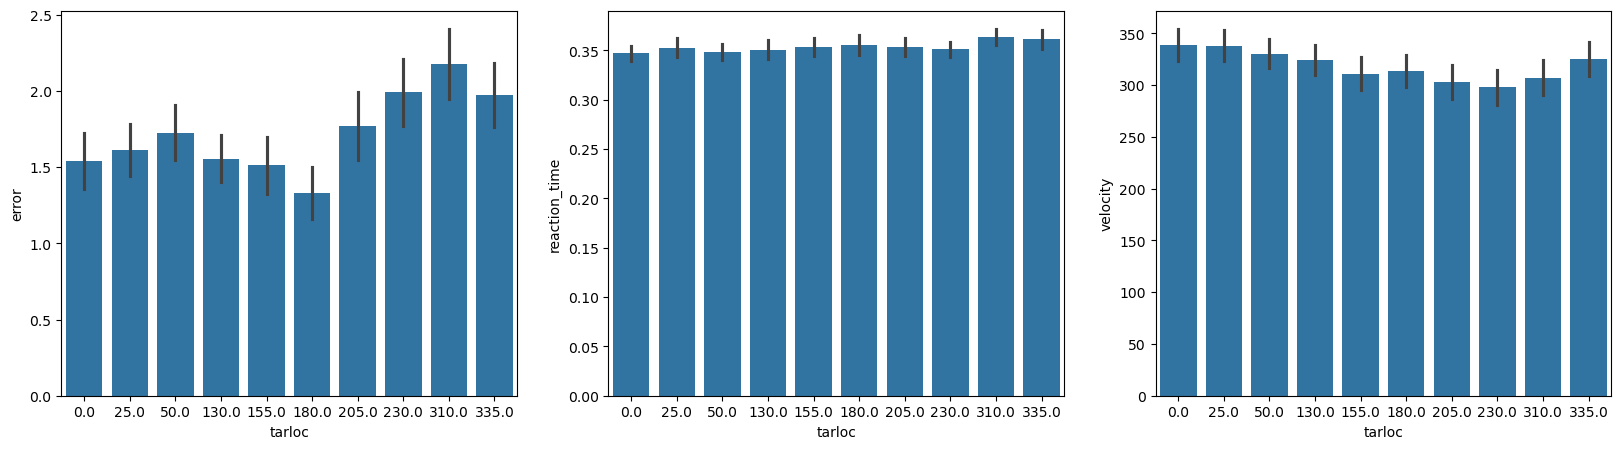

In [3]:
df_filtered = df.copy()
df_filtered = df_filtered[df_filtered['rejtrials'] == 0]
df_filtered = df_filtered[(df_filtered['tarlocCode'] != 11) & (df_filtered['tarlocCode'] != 0)]

df_filtered['tarloc'] = df_filtered['tarloc'].astype(int)
# df_filtered['tarlocRadians'] = np.deg2rad(df_filtered['tarloc'])
tarlocRadians = [np.deg2rad(t) for t in df_filtered['tarloc']]
df_filtered['tarlocRadians'] = tarlocRadians
df_filtered = df_filtered[['subjID', 'rnum', 'tnum', 'error', 'reaction_time', 'velocity',
       'tarloc', 'tarlocCode', 'rejtrials']]
df_grouped = df_filtered.groupby(['subjID', 'tarlocCode']).mean().reset_index()

f, axs = plt.subplots(1, 3, figsize=(20, 5))
sns.barplot(x='tarloc', y='error', data=df_grouped, ax=axs[0], errorbar='se')
sns.barplot(x='tarloc', y='reaction_time', data=df_grouped, ax=axs[1], errorbar='se')
sns.barplot(x='tarloc', y='velocity', data=df_grouped, ax=axs[2], errorbar='se')
# fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
# ax.plot(df_grouped['tarlocRadians'] , df_grouped['error'], '*')
plt.show()

In [42]:
df_grouped.columns

Index(['subjID', 'tarlocCode', 'rnum', 'tnum', 'error', 'reaction_time',
       'velocity', 'tarloc', 'rejtrials', 'tarlocRadians'],
      dtype='object')

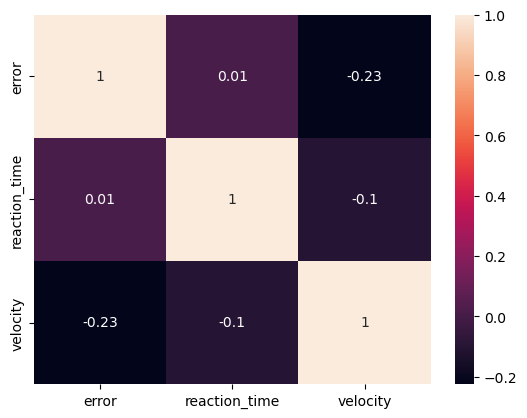

In [4]:
f = plt.figure()
temp = df_grouped[['error', 'reaction_time', 'velocity']]
sns.heatmap(temp.corr(), annot=True)
plt.show()

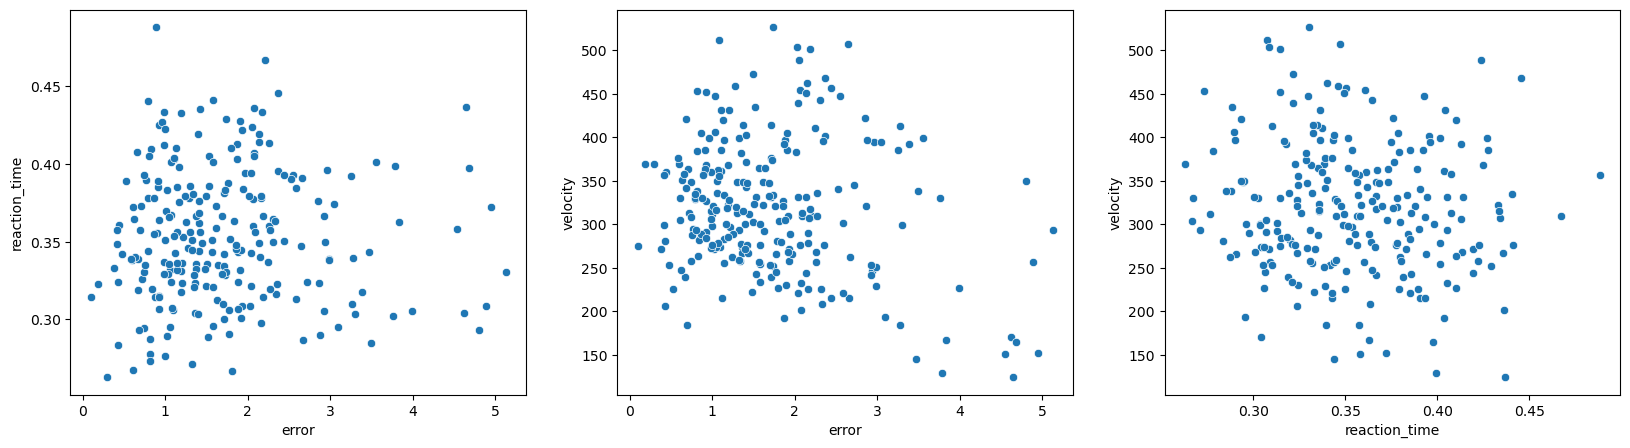

In [5]:
f, axs = plt.subplots(1, 3, figsize=(20, 5))
sns.scatterplot(x='error', y='reaction_time', data=df_grouped, ax=axs[0])
sns.scatterplot(x='error', y='velocity', data=df_grouped, ax=axs[1])
sns.scatterplot(x='reaction_time', y='velocity', data=df_grouped, ax=axs[2])
plt.show()

## Pupil Analysis

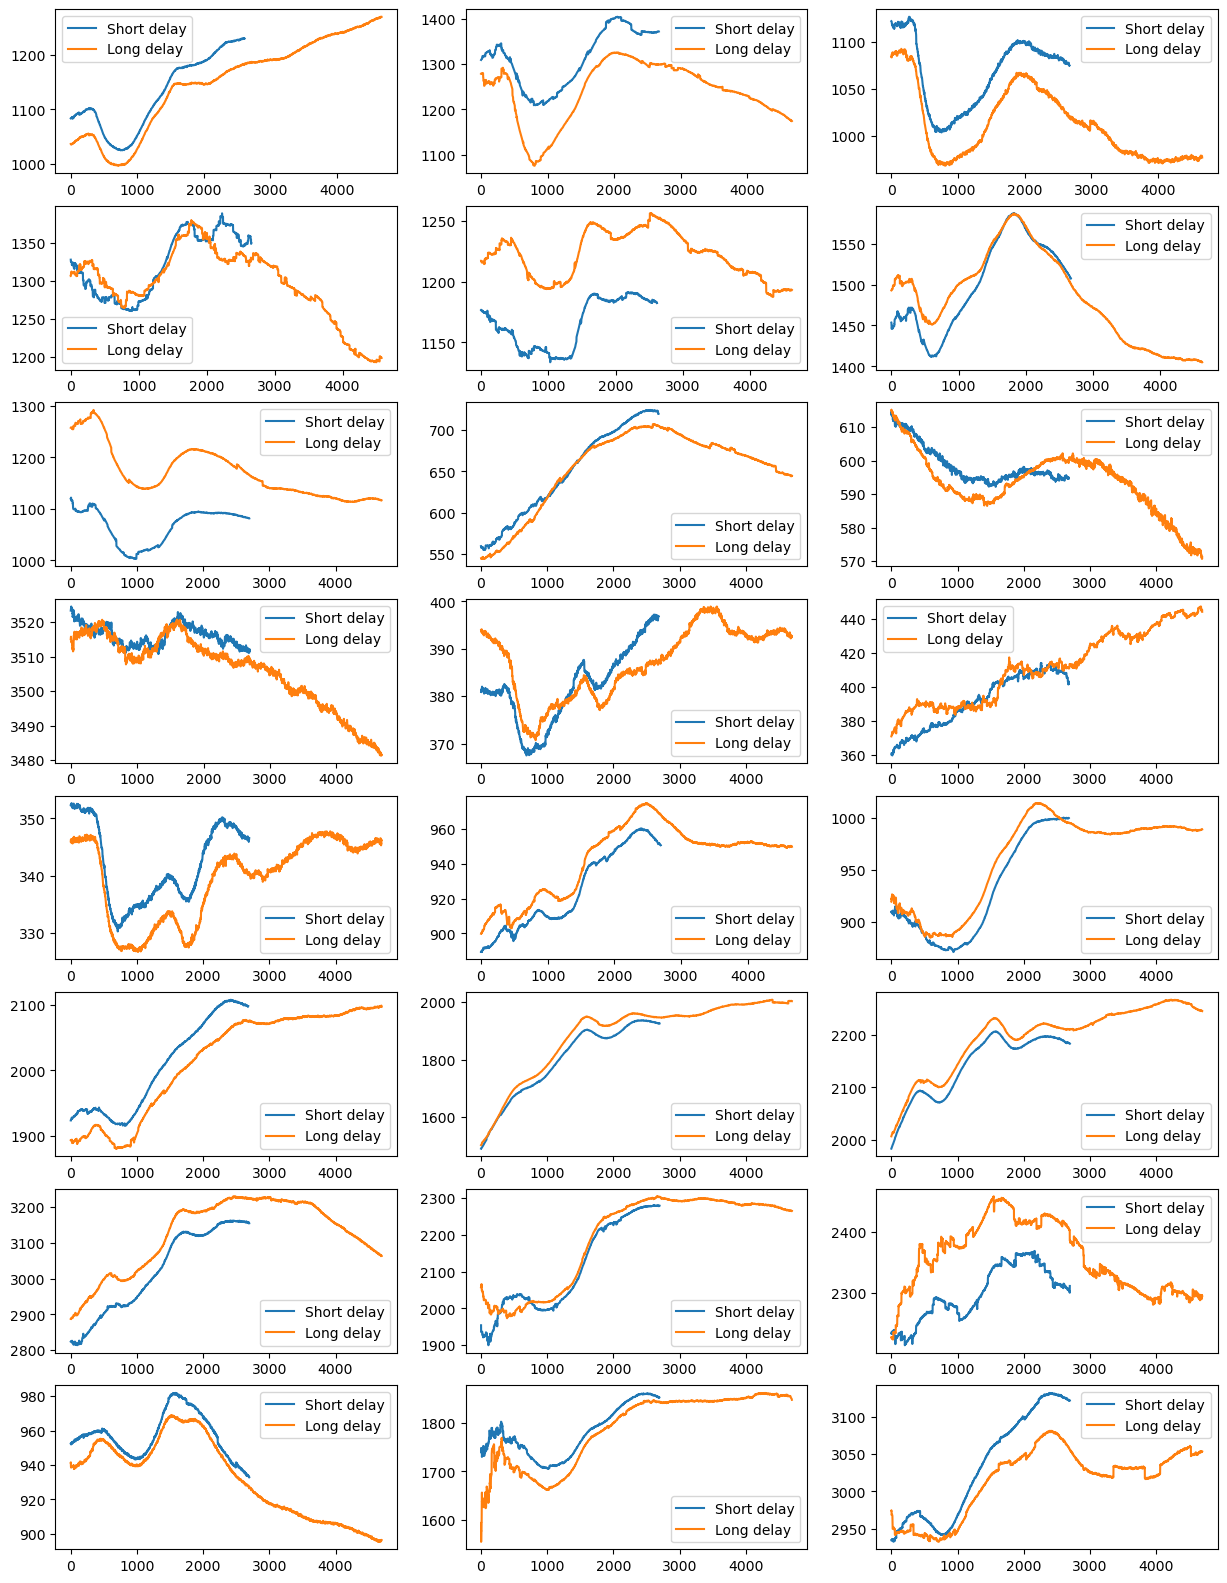

In [51]:
df_pupil = df.copy()
df_pupil = df_pupil[df_pupil['rejtrials'] == 0]
df_pupil = df_pupil[(df_pupil['tarlocCode'] != 11) & (df_pupil['tarlocCode'] != 0)]



# shortPupilMeta = np.empty((len(df_pupil['subjID'].unique()), 3000))
# longPupilMeta = np.empty((len(df_pupil['subjID'].unique()), 5000))
ncols = 3
nrows = len(df_pupil['subjID'].unique()) // ncols
f, axs = plt.subplots(nrows, ncols, figsize=(15, 20))
# f, axs = plt.subplots(2, ncols, figsize=(20, 5))
for sIdx, subjID in enumerate(df_pupil['subjID'].unique()):
# for sIdx, subjID in enumerate([1]):
    df_subj = df_pupil[df_pupil['subjID'] == subjID]
    lenShortMin = 3000
    lenLongMin = 5000
    shrtTrlCount = 0
    longTrlCount = 0
    shortPupil = np.empty((df_subj.shape[0], lenShortMin))
    longPupil = np.empty((df_subj.shape[0], lenLongMin))
    for i in range(df_subj.shape[0]):
        thisTrlX = df_subj['X'].iloc[i]
        thisTrlY = df_subj['Y'].iloc[i]
        thisTrlPupil = df_subj['Pupil'].iloc[i].astype(float)
        thisTrlXDAT = df_subj['XDAT'].iloc[i]
        
        # Select samples where XDAT = 1, 2 or 3
        validXDATSamps = np.where((thisTrlXDAT == 1) | (thisTrlXDAT == 2) | (thisTrlXDAT == 3))[0]
        thisTrlX = thisTrlX[validXDATSamps]
        thisTrlY = thisTrlY[validXDATSamps]
        thisTrlPupil = thisTrlPupil[validXDATSamps]

        # Find samples in X and Y that are nan
        nanSamps = np.where(np.isnan(thisTrlX) | np.isnan(thisTrlY))[0]
        # print(nanSamps)
        # # nan these samples in pupil
        thisTrlPupil[nanSamps] = np.nan

        if len(thisTrlPupil) < 3000: # Short delay
            if len(thisTrlPupil) < lenShortMin:
                lenShortMin = len(thisTrlPupil)
            shortPupil[shrtTrlCount, :len(thisTrlPupil)] = thisTrlPupil.reshape(1, -1)
            shrtTrlCount += 1
        else: # Long delay
            if len(thisTrlPupil) < lenLongMin:
                lenLongMin = len(thisTrlPupil)
            longPupil[longTrlCount, :len(thisTrlPupil)] = thisTrlPupil.reshape(1, -1)
            longTrlCount += 1
        # print(thisTrlPupil.shape)
        # Check if there is nan in X or Y
        # if np.isnan(thisTrlX).any() or np.isnan(thisTrlY).any():
            
        # print(df_sub1['Pupil'].iloc[i].shape)

    # Drop empty rows
    # shortPupil = shortPupil[~np.all(np.isnan(shortPupil), axis=1)]
    # longPupil = longPupil[~np.all(np.isnan(longPupil), axis=1)]
    shortPupil = shortPupil[:shrtTrlCount, :lenShortMin]
    longPupil = longPupil[:longTrlCount, :lenLongMin]

    axs[sIdx // ncols, sIdx % ncols].plot(np.nanmean(shortPupil, axis=0), label='Short delay')
    axs[sIdx // ncols, sIdx % ncols].plot(np.nanmean(longPupil, axis=0), label='Long delay')
    axs[sIdx // ncols, sIdx % ncols].legend()


    # if sIdx == 0:
    #     shortPupilMeta = shortPupil
    #     longPupilMeta = longPupil
    # else:
    #     shortPupilMeta = np.concatenate((shortPupilMeta, shortPupil), axis=0)
    #     longPupilMeta = np.concatenate((longPupilMeta, longPupil), axis=0)

    # shortPupilMeta[sIdx, :] = np.nanmean(shortPupil, axis=0)
    # longPupilMeta[sIdx, :] = np.nanmean(longPupil, axis=0)
plt.show()
    

/users/mrugank/.conda/envs/eegmne/lib/python3.12/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/users/mrugank/.conda/envs/eegmne/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1746: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


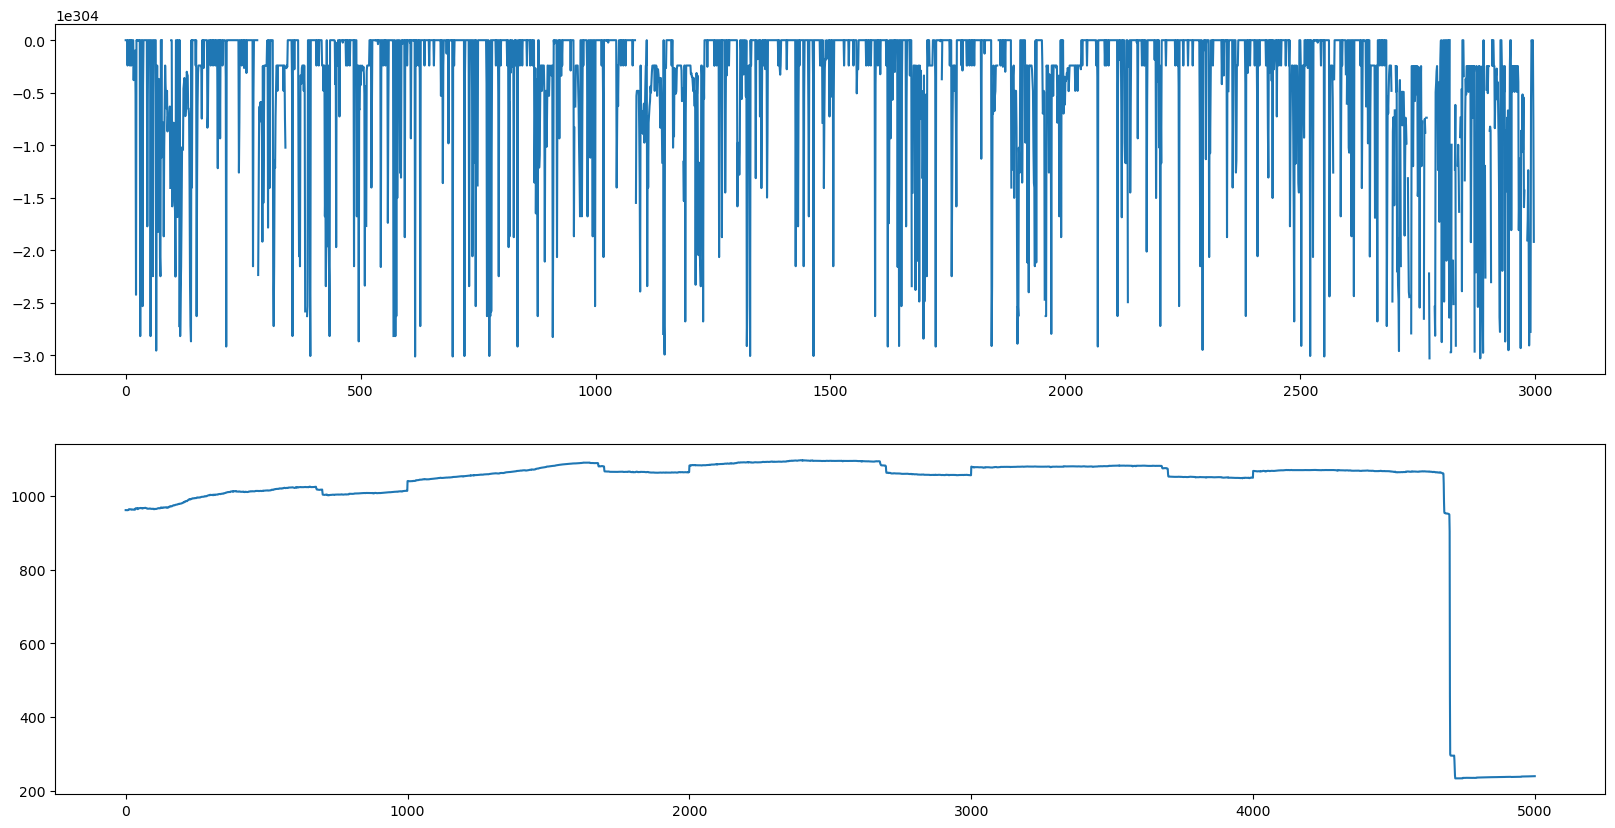

In [ ]:
# Visualize the pupil data
f, axs = plt.subplots(2, 1, figsize=(20, 10))
mean_shortPupil = np.nanmean(shortPupilMeta, axis=0)
mean_longPupil = np.nanmean(longPupilMeta, axis=0)
# sem_shortPupil = np.nanstd(shortPupilMeta, axis=0) / np.sqrt(shortPupilMeta.shape[0])
# sem_longPupil = np.nanstd(longPupilMeta, axis=0) / np.sqrt(longPupilMeta.shape[0])
axs[0].plot(mean_shortPupil, label='Short delay')
# axs[0].fill_between(np.arange(3000), mean_shortPupil - sem_shortPupil, mean_shortPupil + sem_shortPupil, alpha=0.5)
axs[1].plot(mean_longPupil, label='Long delay')
# axs[1].fill_between(np.arange(5000), mean_longPupil - sem_longPupil, mean_longPupil + sem_longPupil, alpha=0.5)
plt.show()
# plt.plot(np.nanmean(shortPupilMeta, axis=0), label='Short delay')
# plt.fill
# plt.plot(np.nanmean(longPupilMeta, axis=0), label='Long delay')
# plt.legend()
# plt.show()

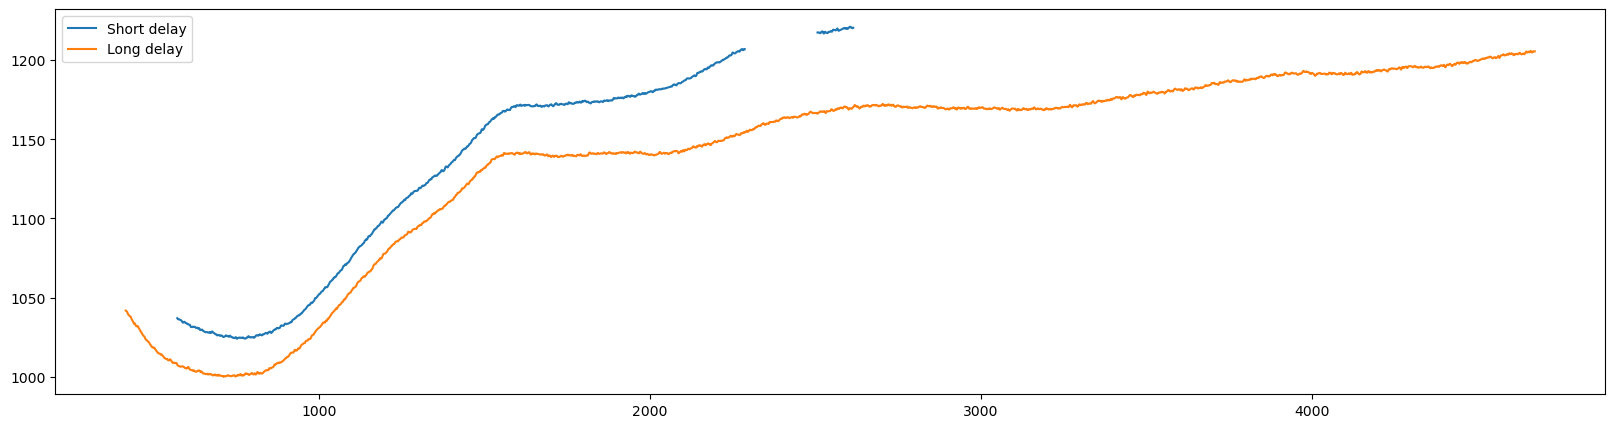

In [47]:
df_sub1 = df[df['subjID'] == 1]

shortPupil = np.empty((df_sub1.shape[0], 3000))
longPupil = np.empty((df_sub1.shape[0], 5000))

lenShortMin = 3000
lenLongMin = 5000
shrtTrlCount = 0
longTrlCount = 0
for i in range(df_sub1.shape[0]):
    thisTrlX = df_sub1['X'].iloc[i]
    thisTrlY = df_sub1['Y'].iloc[i]
    thisTrlPupil = df_sub1['Pupil'].iloc[i].astype(float)
    thisTrlXDAT = df_sub1['XDAT'].iloc[i]
    
    
    # Select samples where XDAT = 1, 2 or 3
    validXDATSamps = np.where((thisTrlXDAT == 1) | (thisTrlXDAT == 2) | (thisTrlXDAT == 3))[0]
    thisTrlX = thisTrlX[validXDATSamps]
    thisTrlY = thisTrlY[validXDATSamps]
    thisTrlPupil = thisTrlPupil[validXDATSamps]
    nanSamps = np.where(np.isnan(thisTrlX) | np.isnan(thisTrlY))[0]
    # print(nanSamps)
    # # nan these samples in pupil
    thisTrlPupil[nanSamps] = np.nan

    if len(thisTrlPupil) < 3000: # Short delay
        if len(thisTrlPupil) < lenShortMin:
            lenShortMin = len(thisTrlPupil)
        shortPupil[shrtTrlCount, :len(thisTrlPupil)] = thisTrlPupil.reshape(1, -1)
        shrtTrlCount += 1
    else: # Long delay
        if len(thisTrlPupil) < lenLongMin:
            lenLongMin = len(thisTrlPupil)
        longPupil[longTrlCount, :len(thisTrlPupil)] = thisTrlPupil.reshape(1, -1)
        longTrlCount += 1
    
    
    # print(thisTrlPupil.shape)
    # Check if there is nan in X or Y
    # if np.isnan(thisTrlX).any() or np.isnan(thisTrlY).any():
        
    # print(df_sub1['Pupil'].iloc[i].shape)

# Drop empty rows
# shortPupil = shortPupil[~np.all(np.isnan(shortPupil), axis=1)]
# longPupil = longPupil[~np.all(np.isnan(longPupil), axis=1)]

# print(shortPupil.shape, longPupil.shape)
shortPupil = shortPupil[:shrtTrlCount, :lenShortMin]
longPupil = longPupil[:longTrlCount, :lenLongMin]

# Plot the average pupil size
# f, axs = plt.subplots(1, 2, figsize=(20, 5))
plt.figure(figsize=(20, 5))
plt.plot(shortPupil.mean(axis=0), label='Short delay')
plt.plot(longPupil.mean(axis=0), label='Long delay')
# plt.ylim([0, 1000])
plt.legend()
plt.show()